**Скрытая Марковская модель (HMM)**

Скрытая Марковская модель - это вероятностная модель последовательности, которая состоит из набора наблюдаемых переменных X = {x1,...,xN} и скрытых
переменных(переменные состояния) T = {t1 ,...,tN}. Целью модели является как можно точнее смоделировать статические свойства источников сигналов.

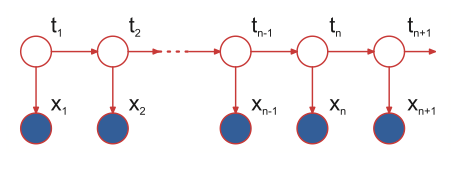

Наблюдаемые переменные - слова

Скрытые переменные - теги

Модель не имеет точной информации о тегах, но знает общие тенденции. Основываясь на том, какие теги были у слов в обучающей выборке, модель пытается угадать, какой тег будет у новых слов.

## Импортируем библиотеки

In [1]:
import nltk
import random
import numpy as np
import pandas as pd
import pprint, time
from tqdm import notebook
from sklearn.model_selection import train_test_split

Для обучения используем материалы Диалог 2017 (General Internet-Corpus of Russian)

## Скачиваем данные

### Либо из google-drive

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

In [ ]:
with open("/content/drive/MyDrive/МСП/gikrya_train.txt") as f:
  data = f.read()

### либо из github

In [2]:
!wget https://raw.githubusercontent.com/appling2024/data/refs/heads/main/GSD_train.txt
!wget https://raw.githubusercontent.com/appling2024/data/refs/heads/main/GSD_test.txt

--2024-11-07 21:18:18--  https://raw.githubusercontent.com/appling2024/data/refs/heads/main/GSD_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7626752 (7,3M) [text/plain]
Saving to: 'GSD_train.txt'

     0K .......... .......... .......... .......... ..........  0%  189K 39s
    50K .......... .......... .......... .......... ..........  1% 31,1M 20s
   100K .......... .......... .......... .......... ..........  2%  987K 15s
   150K .......... .......... .......... .......... ..........  2%  101M 12s
   200K .......... .......... .......... .......... ..........  3% 43,2M 9s
   250K .......... .......... .......... .......... ..........  4% 49,0M 8s
   300K .......... .......... .......... .......... ..........  4% 1,12M 7s
   350K .......... .......... .......... .......... .........

## Анализ данных

Посмотрим, как выглядят наши данные. Выведем первые 3 предложения:

In [2]:
with open("GSD_train.txt", encoding='utf-8') as f:
  data = f.read()
sent = data.split('\n\n')

In [3]:
# представляем данные в виде списка, который содержит другие списки, каждый из
# которых соответствует одному предложению и содержит все слова и их теги в виде кортежа (слово, тег)
tokens = []
for sentence in sent:
    s = []
    for word in sentence.split('\n'):
        if word:
            token = (word.split()[1], word.split()[3])
            s.append(token)
    tokens.append(s)

In [4]:
print(tokens[0:10])

[[('Начальный', 'ADJ'), ('ролик', 'NOUN'), (',', 'PUNCT'), ('или', 'CCONJ'), ('опенинг', 'NOUN'), ('(', 'PUNCT'), ('от', 'ADP'), (',', 'PUNCT'), ('сокр.', 'ADV'), (':', 'PUNCT'), ('OP', 'X'), (')', 'PUNCT'), (',', 'PUNCT'), ('как', 'ADP'), ('правило', 'NOUN'), (',', 'PUNCT'), ('представляет', 'VERB'), ('собой', 'PRON'), ('анимацию', 'NOUN'), (',', 'PUNCT'), ('изображающую', 'VERB'), ('главных', 'ADJ'), ('героев', 'NOUN'), ('аниме', 'NOUN'), ('и', 'CCONJ'), ('отражающую', 'VERB'), ('его', 'DET'), ('стиль', 'NOUN'), ('.', 'PUNCT')], [('Стропило', 'NOUN'), (',', 'PUNCT'), ('означающее', 'VERB'), ('победителя', 'NOUN'), (',', 'PUNCT'), ('окрашено', 'VERB'), ('в', 'ADP'), ('красный', 'ADJ'), ('цвет', 'NOUN'), ('--', 'PUNCT'), ('цвет', 'NOUN'), ('гербового', 'ADJ'), ('щита', 'NOUN'), ('Москвы', 'PROPN'), (',', 'PUNCT'), ('стропило', 'NOUN'), (',', 'PUNCT'), ('означающее', 'VERB'), ('побеждённого', 'VERB'), (',', 'PUNCT'), ('имеет', 'VERB'), ('зелёный', 'ADJ'), ('цвет', 'NOUN'), ('--', 'PUNCT

In [5]:
# смотрим сколько всего у нас предложений
print(len(sent))

4975


## Подготовка к обучению HMM

In [6]:
# делим даннные на обучающую и тестовую выборки в соотношении 80:20
# данные выбираются рандомно, random_state - фиксирует набор
train_set,test_set =train_test_split(tokens, train_size=0.80, test_size=0.20, random_state = 101)

In [7]:
print(len(train_set))
print(len(test_set))

3980
995


In [8]:
# из списка списков создаем список размеченных обучающих и тестовых данных
train_tagged_words = [ tup for sent in train_set for tup in sent ]
test_tagged_words = [ tup for sent in test_set for tup in sent ]
print(len(train_tagged_words))
print(len(test_tagged_words))

77589
19372


In [9]:
# проверяем первые 7 размеченных слов в обучающей выборке
train_tagged_words[:7]

[('Реакция', 'NOUN'),
 ('Мексиканской', 'ADJ'),
 ('биржи', 'NOUN'),
 ('на', 'ADP'),
 ('эти', 'DET'),
 ('изменения', 'NOUN'),
 (',', 'PUNCT')]

In [10]:
tags_list = [tag for word, tag in train_tagged_words]

In [11]:
train_tagged_words = [('ZERO', 'ZERO'), ('ZERO', 'ZERO'),] + train_tagged_words
# train_tagged_words = train_tagged_words

In [12]:
tag_pairs = [(train_tagged_words[i][1], (train_tagged_words[i-2][1], train_tagged_words[i-1][1])) for i in range(2, len(train_tagged_words))]

In [13]:
print(tags_list[:20])
print(tag_pairs[:20])

['NOUN', 'ADJ', 'NOUN', 'ADP', 'DET', 'NOUN', 'PUNCT', 'VERB', 'PRON', 'ADP', 'ADJ', 'NOUN', 'ADP', 'NOUN', 'NUM', 'ADJ', 'NOUN', 'NOUN', 'PUNCT', 'ADV']
[('NOUN', ('ZERO', 'ZERO')), ('ADJ', ('ZERO', 'NOUN')), ('NOUN', ('NOUN', 'ADJ')), ('ADP', ('ADJ', 'NOUN')), ('DET', ('NOUN', 'ADP')), ('NOUN', ('ADP', 'DET')), ('PUNCT', ('DET', 'NOUN')), ('VERB', ('NOUN', 'PUNCT')), ('PRON', ('PUNCT', 'VERB')), ('ADP', ('VERB', 'PRON')), ('ADJ', ('PRON', 'ADP')), ('NOUN', ('ADP', 'ADJ')), ('ADP', ('ADJ', 'NOUN')), ('NOUN', ('NOUN', 'ADP')), ('NUM', ('ADP', 'NOUN')), ('ADJ', ('NOUN', 'NUM')), ('NOUN', ('NUM', 'ADJ')), ('NOUN', ('ADJ', 'NOUN')), ('PUNCT', ('NOUN', 'NOUN')), ('ADV', ('NOUN', 'PUNCT'))]


In [14]:
tags = set(tags_list)
print('Количество уникальных тегов:', len(tags))
print('Набор тегов:', tags)

Количество уникальных тегов: 16
Набор тегов: {'SYM', 'ADP', 'VERB', 'X', 'AUX', 'SCONJ', 'DET', 'ADV', 'PUNCT', 'CCONJ', 'PROPN', 'NOUN', 'PART', 'NUM', 'PRON', 'ADJ'}


In [15]:
tag_pairs_set = set([tp[1] for tp in tag_pairs])
print('Количество уникальных пар тегов:', len(tag_pairs_set))
print('Набор пар тегов:', tag_pairs_set)

Количество уникальных пар тегов: 241
Набор пар тегов: {('NOUN', 'CCONJ'), ('PART', 'PART'), ('VERB', 'NUM'), ('SCONJ', 'PROPN'), ('PUNCT', 'AUX'), ('ADV', 'AUX'), ('VERB', 'ADP'), ('X', 'DET'), ('PROPN', 'AUX'), ('NOUN', 'SYM'), ('DET', 'NOUN'), ('CCONJ', 'ADV'), ('CCONJ', 'NOUN'), ('ADV', 'VERB'), ('PUNCT', 'VERB'), ('VERB', 'PART'), ('AUX', 'PROPN'), ('ADJ', 'PRON'), ('PROPN', 'VERB'), ('PRON', 'PUNCT'), ('SYM', 'PRON'), ('X', 'NOUN'), ('SCONJ', 'PUNCT'), ('PART', 'ADV'), ('NOUN', 'SCONJ'), ('DET', 'PROPN'), ('ADP', 'VERB'), ('AUX', 'PUNCT'), ('DET', 'SCONJ'), ('VERB', 'ADV'), ('ADJ', 'NUM'), ('NUM', 'NUM'), ('X', 'PROPN'), ('SYM', 'NUM'), ('ADJ', 'ADP'), ('NUM', 'ADP'), ('ADV', 'ADJ'), ('SYM', 'ADP'), ('PRON', 'X'), ('SCONJ', 'X'), ('PROPN', 'ADJ'), ('CCONJ', 'PUNCT'), ('ADJ', 'PART'), ('NUM', 'PART'), ('NOUN', 'AUX'), ('AUX', 'X'), ('PART', 'PUNCT'), ('ADP', 'ADJ'), ('NOUN', 'VERB'), ('ADJ', 'ADV'), ('NUM', 'ADV'), ('CCONJ', 'X'), ('ZERO', 'NOUN'), ('VERB', 'PRON'), ('ADV', 'NUM'),

In [16]:
# проверяем количество уникальных словоупотреблений
vocab = {word for word,tag in train_tagged_words}
print('Количество уникальных словоупотреблений:', len(vocab))

Количество уникальных словоупотреблений: 26466


In [17]:
tags_sorted = sorted(tags)
tag_pairs_set_sorted = sorted(tag_pairs_set)

## Принцип обучения HMM

Для каждого состояния скрытой марковской модели задан вектор вероятности эмиссии(выбросов), который характеризует вероятность наблюдения каждого события, когда модель находится в этом состоянии.

В нашем случае эмиссия - "насколько вероятно, что конкретное слово будет иметь конкретный тег".

Совокупность таких векторов образует матрицу эмиссии.

In [18]:
# рассчитываем вероятности эмиссии
# они определяют вероятность увидеть определенную наблюдаемую переменную при заданном значении для скрытых переменных,
# т.е. эта функция возвращает то, сколько всего раз тег встречался в выборке и сколько раз определенное слово встречалось с этим тегом
def word_given_tag(word, tag, train_bag=train_tagged_words):
    tag_list = [pair for pair in train_bag if pair[1]==tag] # список всех слов определенного тега
    count_tag = len(tag_list)# общее число появления тегов в обучающей выборке
    w_given_tag_list = [pair[0] for pair in tag_list if pair[0]==word] # cписок, который состоит из всех вхождений данного слова, которые были помечены определенным тегом
    count_w_given_tag = len(w_given_tag_list) # подсчитываем общее количество раз, когда слово встречалось с тегом

    return (count_w_given_tag, count_tag)

[**Вероятность перехода**](http://stratum.ac.ru/education/textbooks/modelir/lection33.html)

Модель марковского процесса представим в виде графа, в котором состояния (вершины) связаны между собой связями (переходами из i-го состояния в j-е состояние)

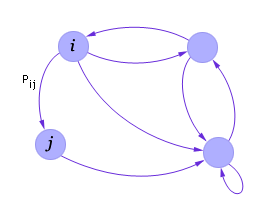

Каждый переход характеризуется вероятностью перехода Pij. Вероятность Pij показывает, как часто после попадания в i-е состояние осуществляется затем переход в j-е состояние.

Таким образом, реализация марковского процесса представляет собой вычисление последовательности (цепи) переходов из состояния в состояние.
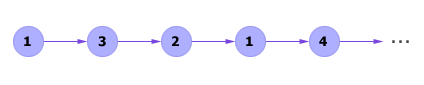



In [19]:
# # рассчитаем вероятность переходов
# def t2_given_t1(t2, t1, train_bag=train_tagged_words): # t1 = t2, это пронумерованный список тегов
#     tags = [pair[1] for pair in train_bag] # список всех тегов по порядку (просто из общего спсика размеченных слов мы убираем слова, получаем последовательность тегов)
#     count_t1 = len([t for t in tags if t==t1])
#     count_t2_t1 = 0
#     for index in range(len(tags)-1):
#         if tags[index]==t1 and tags[index+1] == t2: # если при теге t1 следующий тег = t2, то осуществляется переход
#             count_t2_t1 += 1
#     return (count_t2_t1, count_t1) # сколько всего раз встречается данный (второе значение), сколько раз данный тег переходит в другой тег (первое значение)

In [20]:
# рассчитаем вероятность переходов
def t3_given_t1_and_t2(t3, t1_and_t2, train_bag=train_tagged_words): # t1 = t2, это пронумерованный список тегов
    tag_pairs = [(train_bag[i][1], (train_bag[i-2][1], train_bag[i-1][1])) for i in range(2, len(train_bag))] # список пар тегов по порядку (просто из общего спсика размеченных слов мы убираем слова, получаем последовательность тегов)
    count_t1_and_tw = len([t for t in tag_pairs if t[1]==t1_and_t2])
    count_t3_given_t1_and_t2 = 0
    for index in range(len(tag_pairs)-1):
        if tag_pairs[index][1]==t1_and_t2 and tag_pairs[index+1][0] == t3: # если при теге t1 следующий тег = t2, то осуществляется переход
            count_t3_given_t1_and_t2 += 1
    return (count_t3_given_t1_and_t2, count_t1_and_tw) # сколько всего раз встречается данный (второе значение), сколько раз данный тег переходит в другой тег (первое значение)

In [21]:
# # создаем матрицу тегов t x t, где t - номер тега
# # матрица(i, j) представляет вероятность перехода P(i-й тег переходит в j-й тег)

# tags_matrix = np.zeros((len(tags), len(tags)), dtype='float32')
# for i, t1 in enumerate(list(tags)):
#     for j, t2 in enumerate(list(tags)):
#         tags_matrix[i, j] = t2_given_t1(t2, t1)[0]/t2_given_t1(t2, t1)[1]

# print(tags_matrix)

In [22]:
# создаем матрицу тегов tt x t, где t - номер тега, tt - номер пары тегов
# матрица(i, j) представляет вероятность перехода P(пара (n-2,n-1)-й тегов переходит в n-й тег)

tags_matrix = np.zeros((len(tag_pairs_set_sorted), len(tags_sorted)), dtype='float32')
for i, t1_and_t2 in enumerate(notebook.tqdm(list(tag_pairs_set_sorted))):
    for j, t3 in enumerate(list(tags_sorted)):
        tags_matrix[i, j] = t3_given_t1_and_t2(t3, t1_and_t2)[0]/t3_given_t1_and_t2(t3, t1_and_t2)[1]

# print(tags_matrix)

  0%|          | 0/241 [00:00<?, ?it/s]

**Матрица перехода тегов(состояний)**

Матрица задает вероятность перехода из каждого тега в каждый.

Наглядно модель марковского процесса можно представить себе в виде следующего графа:
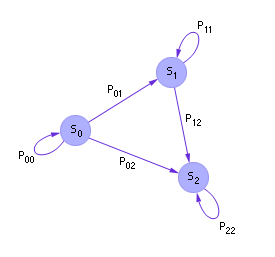


In [ ]:
# tags_df = pd.DataFrame(tags_matrix, columns = list(tags_sorted))
# tags_df.insert(0, 'tag_pair', tag_pairs_set_sorted)
# tags_df.head(50)

In [23]:
tags_df = pd.DataFrame(tags_matrix, columns = list(tags_sorted), index=list(tag_pairs_set_sorted))
tags_df.head(50)

,ADJ,ADP,ADV,AUX,CCONJ,DET,NOUN,NUM,PART,PRON,PROPN,PUNCT,SCONJ,SYM,VERB,X
"(ADJ, ADJ)",0.086643,0.105897,0.007220,0.012034,0.048135,0.008424,0.157641,0.004813,0.002407,0.001203,0.066185,0.448857,0.000000,0.000000,0.043321,0.007220
"(ADJ, ADP)",0.079295,0.057269,0.008811,0.008811,0.035242,0.004405,0.528634,0.008811,0.008811,0.000000,0.057269,0.158590,0.000000,0.000000,0.030837,0.013216
"(ADJ, ADV)",0.230769,0.192308,0.076923,0.000000,0.000000,0.000000,0.192308,0.038462,0.000000,0.000000,0.115385,0.076923,0.000000,0.000000,0.076923,0.000000
"(ADJ, AUX)",0.206897,0.344828,0.000000,0.000000,0.034483,0.034483,0.241379,0.000000,0.034483,0.000000,0.000000,0.068966,0.000000,0.000000,0.034483,0.000000
"(ADJ, CCONJ)",0.117371,0.032864,0.009390,0.000000,0.000000,0.000000,0.615023,0.000000,0.009390,0.009390,0.037559,0.150235,0.000000,0.000000,0.018779,0.000000
"(ADJ, DET)",0.047619,0.285714,0.000000,0.000000,0.000000,0.000000,0.047619,0.000000,0.000000,0.000000,0.000000,0.523810,0.000000,0.000000,0.095238,0.000000
"(ADJ, NOUN)",0.123215,0.128675,0.032064,0.010641,0.031364,0.016662,0.277793,0.023523,0.009521,0.023943,0.082330,0.116074,0.005461,0.001260,0.104593,0.012882
"(ADJ, NUM)",0.000000,0.157895,0.000000,0.052632,0.052632,0.052632,0.263158,0.105263,0.000000,0.052632,0.000000,0.263158,0.000000,0.000000,0.000000,0.000000
"(ADJ, PART)",0.000000,0.181818,0.000000,0.000000,0.000000,0.000000,0.363636,0.000000,0.000000,0.045455,0.045455,0.181818,0.000000,0.000000,0.136364,0.045455
"(ADJ, PRON)",0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.266667,0.066667,0.000000,0.066667,0.000000,0.200000,0.000000,0.000000,0.200000,0.000000


## Алгоритм Витерби

Алгоритм поиска наиболее подходящего списка состояний, который в контексте цепей Маркова получает наиболее вероятную последовательность скрытых состояний с учётом наблюдающейся последовательности в модели.

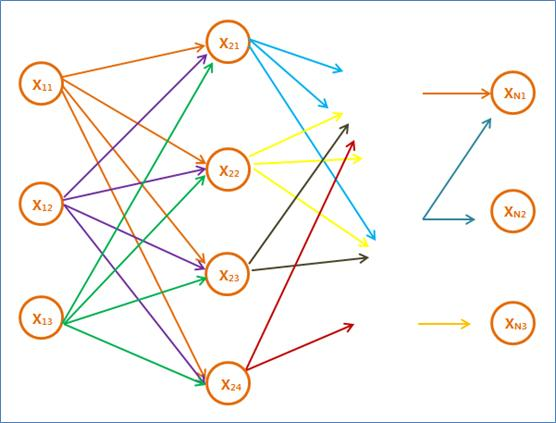

In [24]:
print(train_tagged_words[0:10])

[('ZERO', 'ZERO'), ('ZERO', 'ZERO'), ('Реакция', 'NOUN'), ('Мексиканской', 'ADJ'), ('биржи', 'NOUN'), ('на', 'ADP'), ('эти', 'DET'), ('изменения', 'NOUN'), (',', 'PUNCT'), ('привела', 'VERB')]


In [25]:
# протестируем алгоритм Витерби на нескольких примерах предложений тестового набора данных
random.seed(1234)      #определяем случайное значение

# выбираем случайные 10 значений
rndom = [random.randint(1,len(test_set)) for x in range(10)]

# список из 10 предложений, на которых мы тестируем модель
test_run = [test_set[i] for i in rndom]

# список размеченных слов
test_run_base = [tup for sent in test_run for tup in sent]

# список неразмеченных слов
test_tagged_words = [tup[0] for sent in test_run for tup in sent]

In [26]:
print(len(test_tagged_words))
print(test_run_base)
print(test_tagged_words)

147
[('Двери', 'NOUN'), ('из', 'ADP'), ('вагонов', 'NOUN'), ('поезда', 'NOUN'), ('не', 'PART'), ('открываются', 'VERB'), ('.', 'PUNCT'), ('Назвав', 'VERB'), ('призванную', 'VERB'), ('девушку', 'NOUN'), ('в', 'ADP'), ('честь', 'NOUN'), ('своего', 'DET'), ('кота', 'NOUN'), ('``', 'PUNCT'), ('Танарот', 'PROPN'), ('&#39;&#39;', 'PUNCT'), (',', 'PUNCT'), ('он', 'PRON'), ('тем', 'PRON'), ('самым', 'ADJ'), ('заключает', 'VERB'), ('с', 'ADP'), ('ней', 'PRON'), ('контракт', 'NOUN'), ('хозяина', 'NOUN'), ('и', 'CCONJ'), ('слуги', 'NOUN'), ('.', 'PUNCT'), ('Председатель', 'NOUN'), ('Социал-демократической', 'ADJ'), ('партии', 'NOUN'), ('Боснии', 'PROPN'), ('и', 'CCONJ'), ('Герцеговины', 'PROPN'), ('.', 'PUNCT'), ('Телефонный', 'ADJ'), ('код', 'NOUN'), ('--', 'PUNCT'), ('4739', 'NUM'), ('.', 'PUNCT'), ('В', 'ADP'), ('1942', 'ADJ'), ('году', 'NOUN'), ('был', 'AUX'), ('фактически', 'ADV'), ('заключён', 'VERB'), ('под', 'ADP'), ('домашний', 'ADJ'), ('арест', 'NOUN'), ('.', 'PUNCT'), ('Начиная', 'VERB

### Проверяем скорость и точность алгоритма

In [27]:
tag_pairs = [(train_tagged_words[i], (train_tagged_words[i-2][1], train_tagged_words[i-1][1])) for i in range(2, len(train_tagged_words))]
tag_pairs

[(('Реакция', 'NOUN'), ('ZERO', 'ZERO')),
 (('Мексиканской', 'ADJ'), ('ZERO', 'NOUN')),
 (('биржи', 'NOUN'), ('NOUN', 'ADJ')),
 (('на', 'ADP'), ('ADJ', 'NOUN')),
 (('эти', 'DET'), ('NOUN', 'ADP')),
 (('изменения', 'NOUN'), ('ADP', 'DET')),
 ((',', 'PUNCT'), ('DET', 'NOUN')),
 (('привела', 'VERB'), ('NOUN', 'PUNCT')),
 (('её', 'PRON'), ('PUNCT', 'VERB')),
 (('на', 'ADP'), ('VERB', 'PRON')),
 (('последнее', 'ADJ'), ('PRON', 'ADP')),
 (('место', 'NOUN'), ('ADP', 'ADJ')),
 (('в', 'ADP'), ('ADJ', 'NOUN')),
 (('списке', 'NOUN'), ('NOUN', 'ADP')),
 (('24', 'NUM'), ('ADP', 'NOUN')),
 (('крупнейших', 'ADJ'), ('NOUN', 'NUM')),
 (('бирж', 'NOUN'), ('NUM', 'ADJ')),
 (('мира', 'NOUN'), ('ADJ', 'NOUN')),
 (('.', 'PUNCT'), ('NOUN', 'NOUN')),
 (('Сначала', 'ADV'), ('NOUN', 'PUNCT')),
 (('она', 'PRON'), ('PUNCT', 'ADV')),
 (('подвергалась', 'VERB'), ('ADV', 'PRON')),
 (('очистке', 'NOUN'), ('PRON', 'VERB')),
 (('и', 'CCONJ'), ('VERB', 'NOUN')),
 (('промывке', 'NOUN'), ('NOUN', 'CCONJ')),
 (('.', 'PUNCT

In [29]:
# рассчитываем вероятности эмиссии
# они определяют вероятность увидеть определенную наблюдаемую переменную при заданном значении для скрытых переменных,
# т.е. эта функция возвращает то, сколько всего раз тег встречался в выборке и сколько раз определенное слово встречалось с этим тегом
def word_given_tag(word, tag, train_bag=tag_pairs):
    tag_list = [t[0][0] for t in train_bag if t[0][1]==tag]
    # tag_list = [pair for pair in train_bag if pair[1]==tag] # список всех слов определенного тега
    count_tag = len(tag_list)# общее число появления тегов в обучающей выборке
    w_given_tag_list = [t[0] for t in train_bag if t[0][0]==word] # cписок, который состоит из всех вхождений данного слова, которые были помечены определенным тегом
    count_w_given_tag = len(w_given_tag_list) # подсчитываем общее количество раз, когда слово встречалось с тегом

    return (count_w_given_tag, count_tag)

In [ ]:
def Viterbi(words, train_bag=tag_pairs): # первый аргумент - список слов, которым нам нужно присвоить тег, второй - размеченная обучающая выборка
    state = [['ZERO', 'ZERO'], ['ZERO',]]
    T = list(set([pair[0][1] for pair in train_bag])) # список всех возможных тегов
    # print(f'{T=}')

    for key, word in enumerate(notebook.tqdm(words)): # пронумеровываем список слов, чтобы можно было смотреть на предыдущее
        p = [] # инициализируем список столбцов вероятности для каждого наблюдения
        for tag in T: # считаем вероятность перехода
            if key == 0: # если предыдущего тега нет, то рассматриваем вероятность появления слова после знака препинания, в начале предложения
                transition_p = tags_df.at[('ZERO', 'ZERO'), tag]
            elif key == 1:
                transition_p = tags_df.at[('ZERO', state[-1][0]), tag]
            else: # если предыдущий тег есть, то рассматриваем его
                if len(state[-1]) == 1:
                    transition_p = tags_df.at[state[-2], tag]
                else:
                    transition_p = tags_df.at[state[-1], tag]

            # вычисляем вероятности выбросов и состояний
            emission_p = word_given_tag(words[key], tag)[0]/word_given_tag(words[key], tag)[1] # вероятность выбросов ( насколько вероятно, что конкретное слово будет иметь конкретный тег)
            state_probability = emission_p * transition_p  # вероятность состояний (умножаем веротность того, что слово в принципе встречалось с этим тегом на вероятность перехода)
            p.append(state_probability)

        pmax = max(p) # выбираем максимальное значение из полученного списка
        # получаем наиболее вероятную последовательность скрытых состояний
        state_max = T[p.index(pmax)] # записываем его индекс и находим его соответствие в списке тегов
        if len(state[-1]) < 2:
            state[-1].append(state_max)
            if len(state[-1]) == 2:
                state[-1] = tuple(state[-1])
        else:
            state[-1] = tuple(state[-1])
            state.append([state_max])
    print(len(state), state)
    print(len(words), words)
    out_state = [tag[1] for tag in state if len(state)>1]
    return list(zip(words, out_state))

In [35]:
start = time.time()
tagged_seq = Viterbi(test_tagged_words)
end = time.time() # считаем сколько времени это заняло
difference = end-start
print("Время в секундах: ", difference)

  0%|          | 0/147 [00:00<?, ?it/s]

75 [('NOUN', 'ADP'), ('SYM', 'SYM'), ('X', 'X'), ('X', 'SYM'), ('SYM', 'SYM'), ('SYM', 'X'), ('SYM', 'SYM'), ('X', 'SYM'), ('SYM', 'SYM'), ('X', 'X'), ('X', 'X'), ('X', 'X'), ('X', 'X'), ('X', 'SYM'), ('SYM', 'SYM'), ('X', 'X'), ('SYM', 'X'), ('SYM', 'SYM'), ('SYM', 'X'), ('SYM', 'SYM'), ('X', 'SYM'), ('SYM', 'SYM'), ('X', 'X'), ('X', 'X'), ('X', 'X'), ('SYM', 'SYM'), ('X', 'X'), ('X', 'X'), ('SYM', 'X'), ('SYM', 'SYM'), ('X', 'X'), ('SYM', 'X'), ('SYM', 'SYM'), ('X', 'X'), ('X', 'X'), ('X', 'X'), ('X', 'X'), ('X', 'X'), ('X', 'SYM'), ('SYM', 'SYM'), ('SYM', 'SYM'), ('SYM', 'SYM'), ('X', 'SYM'), ('SYM', 'SYM'), ('X', 'SYM'), ('SYM', 'SYM'), ('X', 'X'), ('SYM', 'X'), ('SYM', 'SYM'), ('SYM', 'SYM'), ('X', 'X'), ('SYM', 'X'), ('SYM', 'SYM'), ('SYM', 'X'), ('SYM', 'SYM'), ('SYM', 'X'), ('SYM', 'SYM'), ('SYM', 'SYM'), ('X', 'X'), ('SYM', 'SYM'), ('X', 'X'), ('X', 'SYM'), ('SYM', 'SYM'), ('X', 'SYM'), ('SYM', 'SYM'), ('X', 'SYM'), ('SYM', 'SYM'), ('SYM', 'X'), ('SYM', 'SYM'), ('X', 'SYM'), (

IndexError: list index out of range

In [106]:
# проходим по парам (разметка_HMM, разметка_эталон) и если совпали, сохраняем в список
# по существу, нам просто нужно получить количество совпадений
check = [i for i, j in zip(tagged_seq, test_run_base) if i == j]

accuracy = len(check)/len(tagged_seq) # считаем точность
print('Точность алгоритма Витерби, %: ',accuracy*100)

Точность алгоритма Витерби, %:  6.756756756756757


## Ручная проверка

In [107]:
# Сравним глазами нашу и эталонную разметку
for our, reference in list(zip(tagged_seq, test_run_base))[:12]:
  print('Наша: {0:20}\tЭталон: {1:20}'.format(str(our), str(reference)))

Наша: ('Двери', 'PUNCT')  	Эталон: ('Двери', 'NOUN')   
Наша: ('из', 'PART')      	Эталон: ('из', 'ADP')       
Наша: ('вагонов', 'SCONJ')	Эталон: ('вагонов', 'NOUN') 
Наша: ('поезда', 'AUX')   	Эталон: ('поезда', 'NOUN')  
Наша: ('не', 'PUNCT')     	Эталон: ('не', 'PART')      
Наша: ('открываются', 'PART')	Эталон: ('открываются', 'VERB')
Наша: ('.', 'SCONJ')      	Эталон: ('.', 'PUNCT')      
Наша: ('Назвав', 'AUX')   	Эталон: ('Назвав', 'VERB')  
Наша: ('призванную', 'ADP')	Эталон: ('призванную', 'VERB')
Наша: ('девушку', 'SYM')  	Эталон: ('девушку', 'NOUN') 
Наша: ('в', 'X')          	Эталон: ('в', 'ADP')        
Наша: ('честь', 'X')      	Эталон: ('честь', 'NOUN')   


## Источники:

1. A Guide to Hidden Markov Model and its Applications in NLP (https://analyticsindiamag.com/a-guide-to-hidden-markov-model-and-its-applications-in-nlp/)

2. Датасет: General Internet-Corpus of Russian (https://github.com/dialogue-evaluation/morphoRuEval-2017/blob/master/Baseline.zip)